In [27]:
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from wordcloud import WordCloud
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import nltk
import joblib
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, confusion_matrix,accuracy_score, f1_score,precision_recall_fscore_support)

nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)
nltk.download('punkt',     quiet=True)

True

## Load Data

In [2]:
df = pd.read_csv('resume/Resume.csv')

In [3]:
df.head()

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [4]:
df.shape

(2484, 4)

In [5]:
list(df.columns)

['ID', 'Resume_str', 'Resume_html', 'Category']

In [6]:
df.isnull().sum()

ID             0
Resume_str     0
Resume_html    0
Category       0
dtype: int64

In [7]:
df['Category'].nunique()

24

In [8]:
sorted(df['Category'].unique())

['ACCOUNTANT',
 'ADVOCATE',
 'AGRICULTURE',
 'APPAREL',
 'ARTS',
 'AUTOMOBILE',
 'AVIATION',
 'BANKING',
 'BPO',
 'BUSINESS-DEVELOPMENT',
 'CHEF',
 'CONSTRUCTION',
 'CONSULTANT',
 'DESIGNER',
 'DIGITAL-MEDIA',
 'ENGINEERING',
 'FINANCE',
 'FITNESS',
 'HEALTHCARE',
 'HR',
 'INFORMATION-TECHNOLOGY',
 'PUBLIC-RELATIONS',
 'SALES',
 'TEACHER']

## Exploratory Data Analysis (EDA)

### Category Distribution & Resume Word Count 

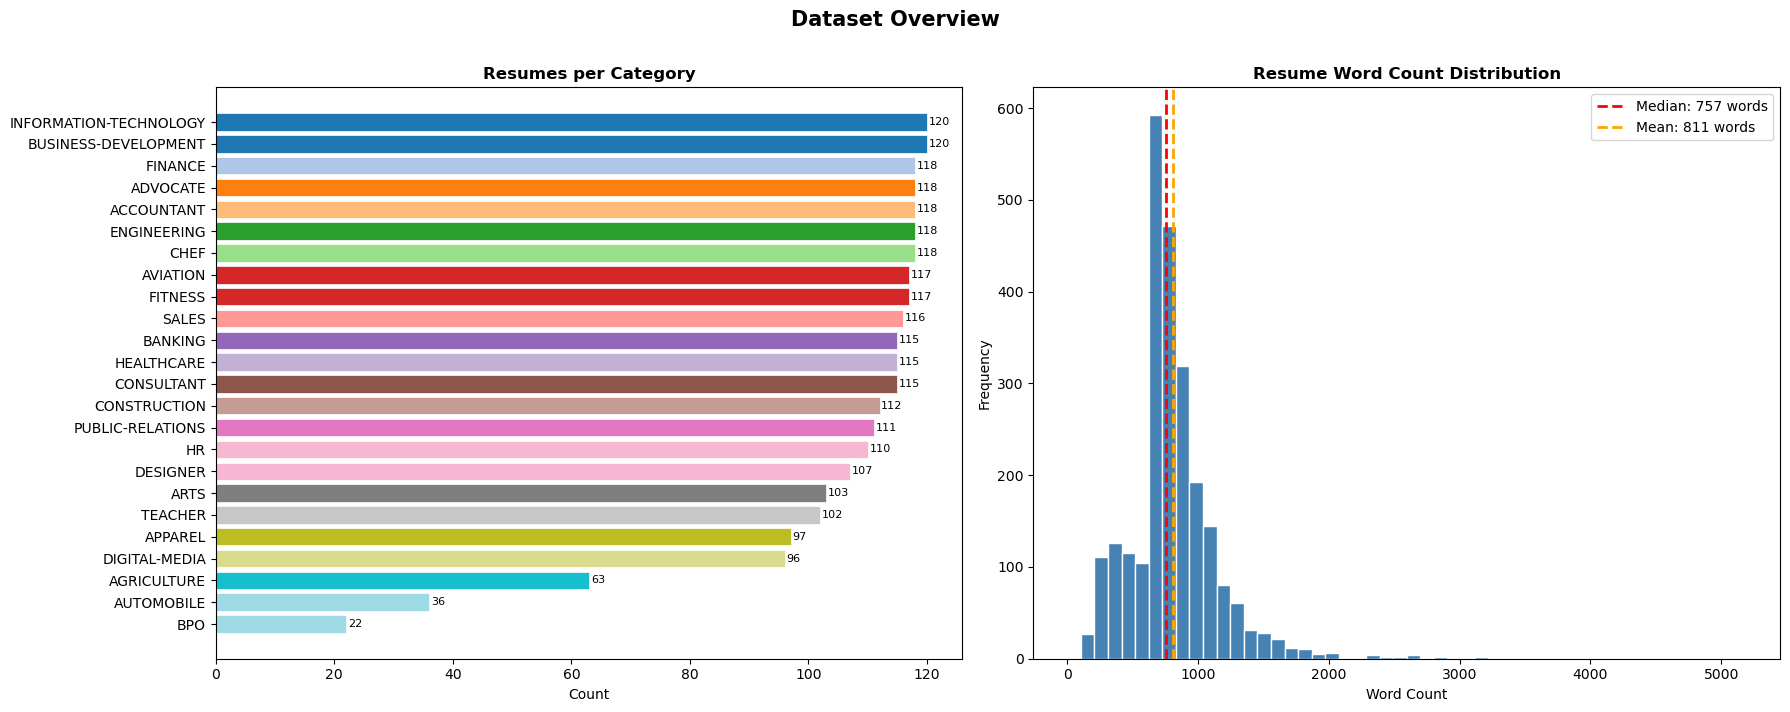

Class imbalance ratio : 5.5x
Avg resume length     : 811 words
Min / Max words       : 0 / 5190


In [9]:
df['word_count'] = df['Resume_str'].apply(lambda x: len(str(x).split()))
cat_counts       = df['Category'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Dataset Overview', fontsize=15, fontweight='bold', y=1.01)


# Bar chart 
colors = plt.cm.tab20(np.linspace(0, 1, len(cat_counts)))
bars   = axes[0].barh(cat_counts.index, cat_counts.values,
                      color=colors, edgecolor='white', linewidth=0.5)
axes[0].set_title('Resumes per Category', fontweight='bold')
axes[0].set_xlabel('Count')
axes[0].invert_yaxis()
for bar, val in zip(bars, cat_counts.values):
    axes[0].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
                 str(val), va='center', fontsize=8)


#  Word-count histogram 
axes[1].hist(df['word_count'], bins=50, color='steelblue', edgecolor='white')
axes[1].axvline(df['word_count'].median(), color='red', linestyle='--', lw=2,
                label=f"Median: {int(df['word_count'].median())} words")
axes[1].axvline(df['word_count'].mean(), color='orange', linestyle='--', lw=2,
                label=f"Mean: {int(df['word_count'].mean())} words")
axes[1].set_title('Resume Word Count Distribution', fontweight='bold')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.show()


print(f"Class imbalance ratio : {cat_counts.max() / cat_counts.min():.1f}x")
print(f"Avg resume length     : {int(df['word_count'].mean())} words")
print(f"Min / Max words       : {df['word_count'].min()} / {df['word_count'].max()}")

### Word Clouds for 6 Sample Categories

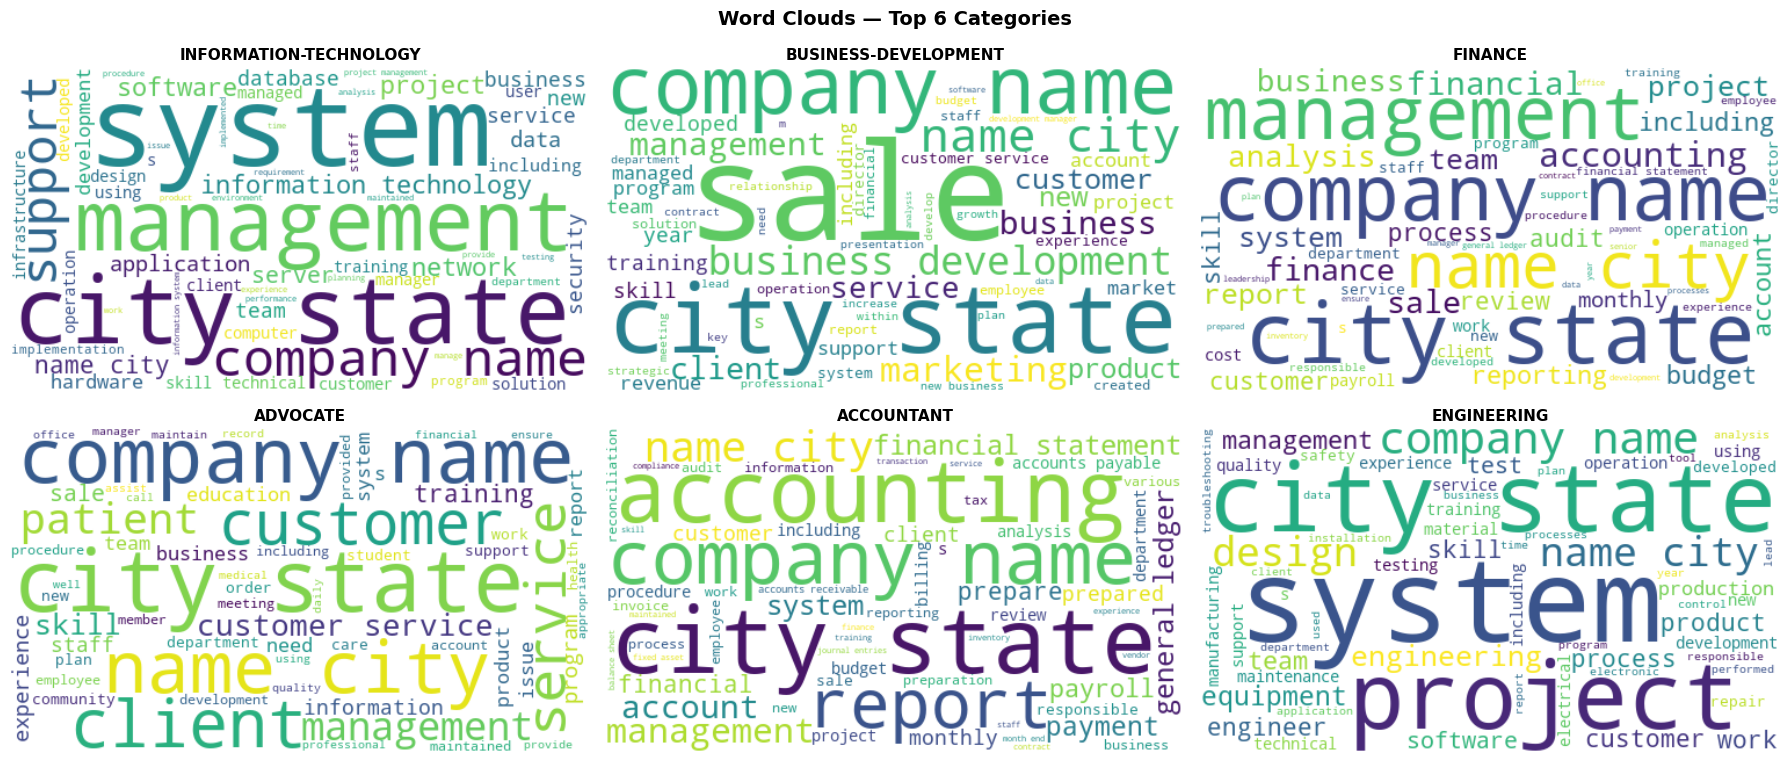

In [10]:
def make_wordcloud(category, df):
    text = ' '.join(df[df['Category'] == category]['Resume_str'].dropna().tolist())
    text = re.sub(r'http\S+|www\.\S+|\S+@\S+', ' ', text.lower())
    text = re.sub(r'[^a-z\s]', ' ', text)
    return WordCloud(width=500, height=280, background_color='white',
                     colormap='viridis', max_words=60).generate(text)

SHOW_CATS = df['Category'].value_counts().head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
fig.suptitle('Word Clouds — Top 6 Categories', fontsize=14, fontweight='bold')
axes = axes.flatten()

for ax, cat in zip(axes, SHOW_CATS):
    wc = make_wordcloud(cat, df)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(cat, fontweight='bold', fontsize=11)
    ax.axis('off')

plt.tight_layout()
plt.show()

## Text Preprocessing

### Preprocessing Pipeline

In [11]:
lemmatizer = WordNetLemmatizer()
STOPS      = set(stopwords.words('english'))

In [12]:
def preprocess(text: str) -> str:
    """
    Clean and normalize resume text:
    1. Lowercase
    2. Remove URLs, emails, special characters
    3. Tokenize, remove stopwords, lemmatize
    """
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = re.sub(r'http\S+|www\.\S+|\S+@\S+', ' ', text)   # URLs & emails
    text = re.sub(r'[^a-z\s]', ' ', text)                        # special chars
    text = re.sub(r'\s+', ' ', text).strip()                     # extra whitespace
    tokens = [
        lemmatizer.lemmatize(w)
        for w in text.split()
        if w not in STOPS and len(w) > 2
    ]
    return ' '.join(tokens)

In [13]:
df['clean'] = df['Resume_str'].apply(preprocess)
df['clean_word_count'] = df['clean'].apply(lambda x: len(x.split()))

In [14]:
print("\n[BEFORE]:", df['Resume_str'].iloc[0][:200])
print("\n[AFTER] :", df['clean'].iloc[0][:200])
print(f"\nAvg tokens after cleaning: {int(df['clean_word_count'].mean())}")
print(f"Empty resumes after clean : {(df['clean'].str.strip() == '').sum()}")


[BEFORE]:          HR ADMINISTRATOR/MARKETING ASSOCIATE

HR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Resp

[AFTER] : administrator marketing associate administrator summary dedicated customer service manager year experience hospitality customer service management respected builder leader customer focused team strive

Avg tokens after cleaning: 583
Empty resumes after clean : 1


## Feature Engineering & Train/Test Split

### Label Encoding

In [15]:
le = LabelEncoder()
df['label'] = le.fit_transform(df['Category'])
NUM_CLASSES  = len(le.classes_)

In [16]:
X = df['clean'].values
y = df['label'].values

### Spliting in Traning and Testing

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size : {len(X_train)} | Test size : {len(X_test)}")
print(f"Classes    : {NUM_CLASSES}")
print(f"\nClass labels: {list(le.classes_)}")

Train size : 1987 | Test size : 497
Classes    : 24

Class labels: ['ACCOUNTANT', 'ADVOCATE', 'AGRICULTURE', 'APPAREL', 'ARTS', 'AUTOMOBILE', 'AVIATION', 'BANKING', 'BPO', 'BUSINESS-DEVELOPMENT', 'CHEF', 'CONSTRUCTION', 'CONSULTANT', 'DESIGNER', 'DIGITAL-MEDIA', 'ENGINEERING', 'FINANCE', 'FITNESS', 'HEALTHCARE', 'HR', 'INFORMATION-TECHNOLOGY', 'PUBLIC-RELATIONS', 'SALES', 'TEACHER']


## Model Building & Cross-Validation

### TF-IDF Params (shared)

In [18]:
TFIDF_PARAMS = dict(
    max_features = 15000,
    ngram_range  = (1, 2),      # unigrams + bigrams
    sublinear_tf = True,        # log normalization
    min_df       = 2            # ignore very rare terms
)

TFIDF_PARAMS_MNB = {**TFIDF_PARAMS, 'sublinear_tf': False}

### Pipelines

In [19]:
pipelines = {
    'Logistic Regression': Pipeline([
        ('tfidf', TfidfVectorizer(**TFIDF_PARAMS)),
        ('clf',   LogisticRegression(
            max_iter=1000, C=5.0,
            multi_class='multinomial',
            class_weight='balanced',   # handles class imbalance
            random_state=42
        ))
    ]),
    'Linear SVM': Pipeline([
        ('tfidf', TfidfVectorizer(**TFIDF_PARAMS)),
        ('clf',   CalibratedClassifierCV(          # proper probability estimates
            LinearSVC(max_iter=2000, C=1.0,
                      class_weight='balanced',
                      random_state=42)
        ))
    ]),
    'Naive Bayes': Pipeline([
        ('tfidf', TfidfVectorizer(**TFIDF_PARAMS_MNB)),
        ('clf',   MultinomialNB(alpha=0.1))
    ])
}

### 5-Fold Stratified Cross-Validation 

In [21]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}
print(f"{'Model':<25s}  {'CV F1 Mean':>12}  {'Std':>8}")
print("─" * 50)

for name, pipe in pipelines.items():
    scores = cross_val_score(
        pipe, X_train, y_train,
        cv=cv, scoring='f1_weighted', n_jobs=-1
    )
    cv_results[name] = scores
    print(f"{name:<25s}  {scores.mean()*100:>10.2f}%  ±{scores.std()*100:>5.2f}%")

Model                        CV F1 Mean       Std
──────────────────────────────────────────────────
Logistic Regression             65.40%  ± 1.58%
Linear SVM                      68.96%  ± 1.02%
Naive Bayes                     54.14%  ± 1.86%


### CV Results Bar Chart

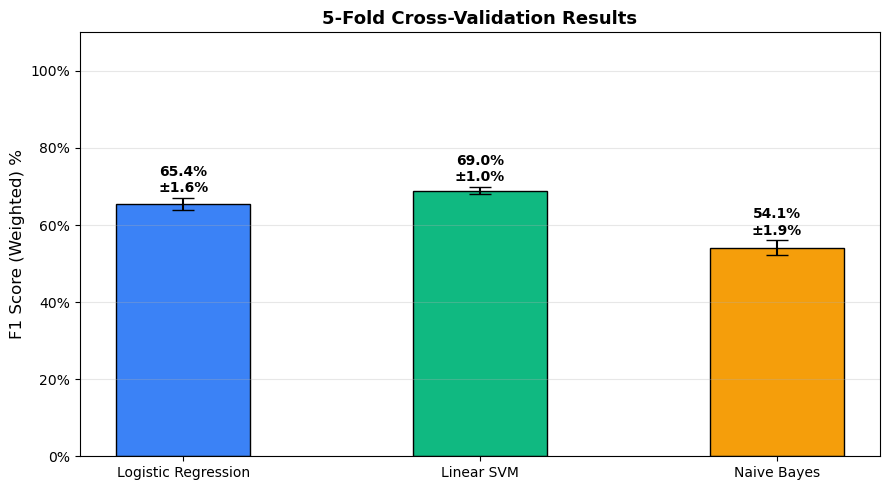

Best model: Linear SVM  (68.96%)


In [22]:
fig, ax = plt.subplots(figsize=(9, 5))

names   = list(cv_results.keys())
means   = [cv_results[n].mean() * 100 for n in names]
stds    = [cv_results[n].std()  * 100 for n in names]
colors  = ['#3B82F6', '#10B981', '#F59E0B']

bars = ax.bar(names, means, yerr=stds, color=colors,
              edgecolor='black', capsize=8, width=0.45)
ax.set_ylabel('F1 Score (Weighted) %', fontsize=12)
ax.set_title('5-Fold Cross-Validation Results', fontsize=13, fontweight='bold')
ax.set_ylim(0, 110)
ax.grid(axis='y', alpha=0.3)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

for bar, mean, std in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + std + 1.5,
            f'{mean:.1f}%\n±{std:.1f}%',
            ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

best_model_name = max(cv_results, key=lambda n: cv_results[n].mean())
print(f"Best model: {best_model_name}  ({cv_results[best_model_name].mean()*100:.2f}%)")

## Final Evaluation on Test Set

### Train best model on full training data

In [23]:
best_pipe = pipelines[best_model_name]
best_pipe.fit(X_train, y_train)

y_pred = best_pipe.predict(X_test)

test_acc = accuracy_score(y_test, y_pred) * 100
test_f1  = f1_score(y_test, y_pred, average='weighted') * 100

print(f"Model         : {best_model_name}")
print(f"Test Accuracy : {test_acc:.2f}%")
print(f"Test F1 (W)   : {test_f1:.2f}%")
print("\n" + "─"*60)
print(classification_report(y_test, y_pred, target_names=le.classes_))

Model         : Linear SVM
Test Accuracy : 73.44%
Test F1 (W)   : 73.00%

────────────────────────────────────────────────────────────
                        precision    recall  f1-score   support

            ACCOUNTANT       0.80      0.83      0.82        24
              ADVOCATE       0.53      0.71      0.61        24
           AGRICULTURE       0.89      0.62      0.73        13
               APPAREL       0.70      0.37      0.48        19
                  ARTS       0.67      0.48      0.56        21
            AUTOMOBILE       1.00      0.29      0.44         7
              AVIATION       0.86      0.79      0.83        24
               BANKING       0.86      0.78      0.82        23
                   BPO       0.33      0.25      0.29         4
  BUSINESS-DEVELOPMENT       0.70      0.88      0.78        24
                  CHEF       0.85      0.71      0.77        24
          CONSTRUCTION       0.75      0.82      0.78        22
            CONSULTANT       0.7

### Confusion Matrix

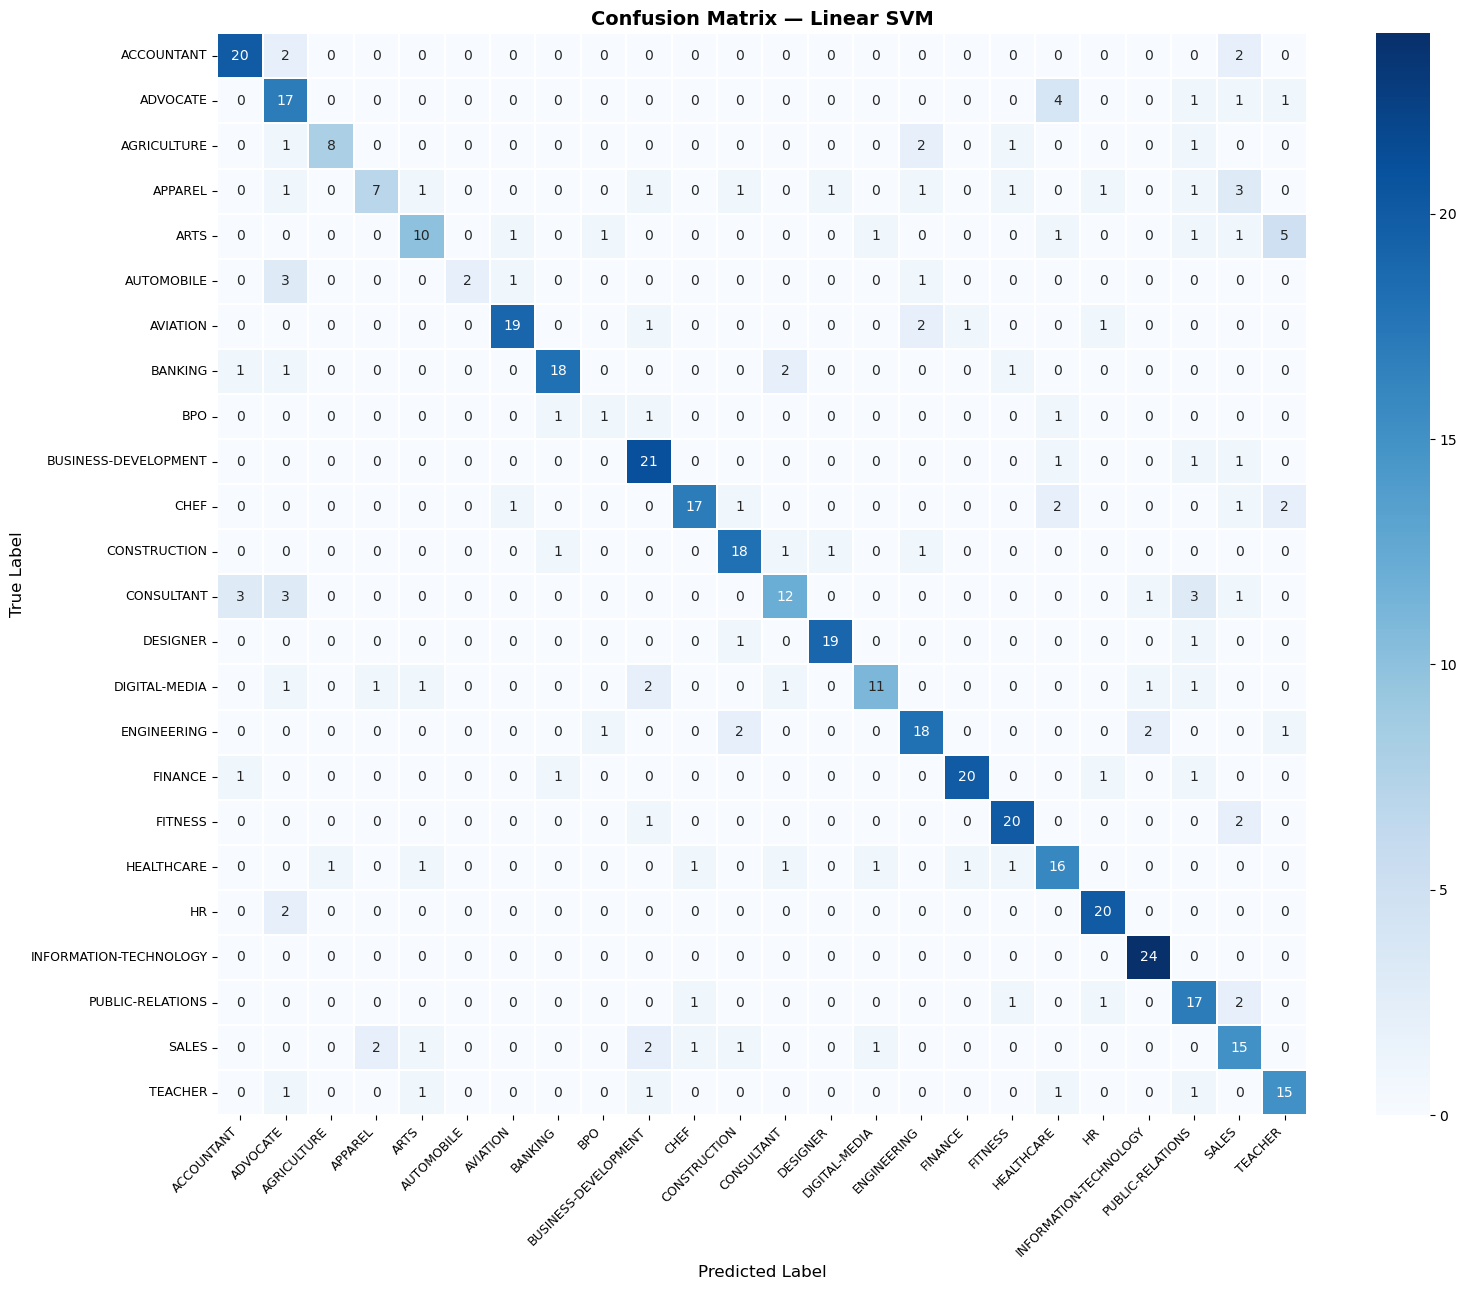

In [24]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(16, 13))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=le.classes_, yticklabels=le.classes_,
            linewidths=0.3, linecolor='white')

ax.set_title(f'Confusion Matrix — {best_model_name}', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

### Per-Category F1: Best vs Worst

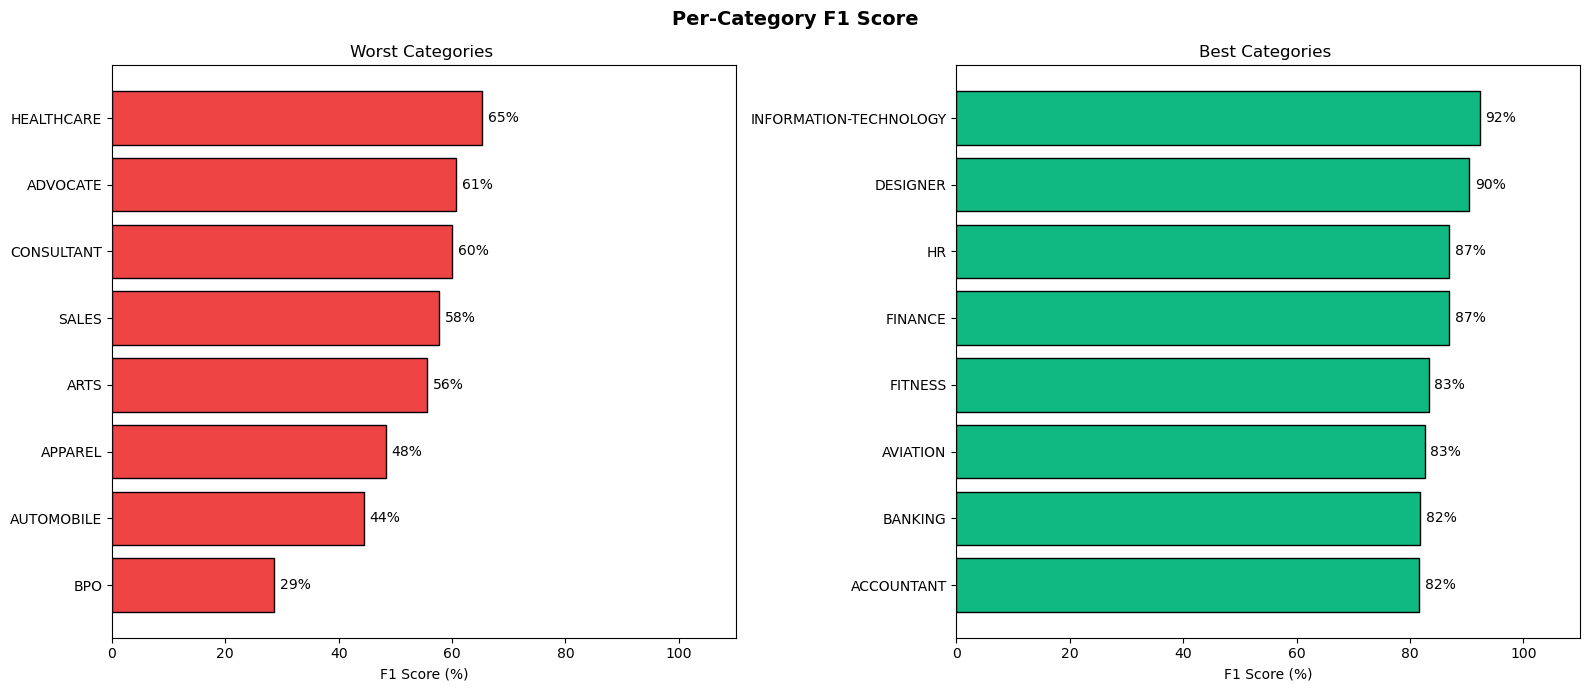


 Worst 3 categories (model confuses these):
  Category       F1  Precision   Recall  Support
       BPO 0.285714   0.333333 0.250000        4
AUTOMOBILE 0.444444   1.000000 0.285714        7
   APPAREL 0.482759   0.700000 0.368421       19


In [25]:
prec, rec, f1s, sup = precision_recall_fscore_support(
    y_test, y_pred, average=None, zero_division=0
)
cat_df = pd.DataFrame({
    'Category' : le.classes_,
    'F1'       : f1s,
    'Precision': prec,
    'Recall'   : rec,
    'Support'  : sup
}).sort_values('F1')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Per-Category F1 Score', fontsize=14, fontweight='bold')


# Worst 8
w = cat_df.head(8)
axes[0].barh(w['Category'], w['F1'] * 100, color='#EF4444', edgecolor='black')
axes[0].set_title('Worst Categories ', fontsize=12)
axes[0].set_xlabel('F1 Score (%)')
axes[0].set_xlim(0, 110)
for i, (_, row) in enumerate(w.iterrows()):
    axes[0].text(row['F1'] * 100 + 1, i, f"{row['F1']*100:.0f}%", va='center')


# Best 8
b = cat_df.tail(8)
axes[1].barh(b['Category'], b['F1'] * 100, color='#10B981', edgecolor='black')
axes[1].set_title('Best Categories ', fontsize=12)
axes[1].set_xlabel('F1 Score (%)')
axes[1].set_xlim(0, 110)
for i, (_, row) in enumerate(b.iterrows()):
    axes[1].text(row['F1'] * 100 + 1, i, f"{row['F1']*100:.0f}%", va='center')

plt.tight_layout()
plt.show()

print("\n Worst 3 categories (model confuses these):")
print(cat_df.head(3)[['Category', 'F1', 'Precision', 'Recall', 'Support']].to_string(index=False))

## Save Model & Label Encoder

In [28]:
MODEL_DIR = Path('models')
MODEL_DIR.mkdir(exist_ok=True)

joblib.dump(best_pipe, MODEL_DIR / 'resume_classifier.pkl')
joblib.dump(le,        MODEL_DIR / 'label_encoder.pkl')

print(f"Model saved      : {MODEL_DIR / 'resume_classifier.pkl'}")
print(f"Encoder saved    : {MODEL_DIR / 'label_encoder.pkl'}")
print(f"\nModel size: {(MODEL_DIR / 'resume_classifier.pkl').stat().st_size / 1024:.1f} KB")

Model saved      : models\resume_classifier.pkl
Encoder saved    : models\label_encoder.pkl

Model size: 14635.5 KB


## Load Model & Predict New Resumes

In [29]:
loaded_pipe = joblib.load(MODEL_DIR / 'resume_classifier.pkl')
loaded_le   = joblib.load(MODEL_DIR / 'label_encoder.pkl')

print("Model loaded successfully from disk")

Model loaded successfully from disk


### Inference Function 

In [30]:
def predict_resume(text: str, top_k: int = 3, pipe=loaded_pipe, encoder=loaded_le) -> dict:
    """
    Predict job category for a given resume text.

    Args:
        text  : Raw resume text (string)
        top_k : Number of top predictions to return (default 3)
    
    Returns:
        dict with 'prediction', 'confidence', 'top_k_predictions'
    """
    cleaned  = preprocess(text)
    probs    = pipe.predict_proba([cleaned])[0]   # CalibratedClassifierCV gives proper probs
    top_idx  = probs.argsort()[::-1][:top_k]

    results = [
        {'rank': i+1, 'category': encoder.classes_[idx], 'confidence': round(probs[idx]*100, 2)}
        for i, idx in enumerate(top_idx)
    ]

    print(f"\n{'═'*50}")
    print(f"  RESUME CATEGORY PREDICTIONS")
    print(f"{'═'*50}")
    for r in results:
        bar = '' * int(r['confidence'] / 4)
        print(f"  #{r['rank']}  {r['category']:<25s} {r['confidence']:5.1f}%  {bar}")
    print(f"{'═'*50}\n")

    return {
        'prediction'      : results[0]['category'],
        'confidence'      : results[0]['confidence'],
        'top_k_predictions': results
    }

In [31]:
# ── Test Case

print("── TEST 1: Data Science Resume ──")
predict_resume("""
    Experienced Data Scientist with 4 years expertise in Python, machine learning,
    deep learning, NLP, TensorFlow, PyTorch, scikit-learn.
    Built recommendation systems, fraud detection models, churn prediction.
    Strong in SQL, Spark, statistics, A/B testing, data visualization with Tableau.
    Published research in computer vision. Kaggle competitions.
""")

print("── TEST 2: HR Resume ──")
predict_resume("""
    HR Manager with 5 years experience in recruitment, talent acquisition,
    employee relations, onboarding, payroll, performance management.
    Skilled in HRMS, SAP SuccessFactors, conflict resolution, labor law compliance.
    Conducted 200+ interviews. Built internship programs for campus hiring.
""")

print("── TEST 3: Finance Resume ──")
predict_resume("""
    Chartered Accountant with expertise in financial reporting, auditing, taxation,
    budgeting, forecasting, and IFRS compliance. Proficient in Tally, SAP FICO.
    Managed accounts for Fortune 500 clients. CPA certified.
    Experience in investment analysis, portfolio management, equity research.
""")

── TEST 1: Data Science Resume ──

══════════════════════════════════════════════════
  RESUME CATEGORY PREDICTIONS
══════════════════════════════════════════════════
  #1  AGRICULTURE                14.7%  
  #2  ENGINEERING                14.0%  
  #3  CONSULTANT                 10.3%  
══════════════════════════════════════════════════

── TEST 2: HR Resume ──

══════════════════════════════════════════════════
  RESUME CATEGORY PREDICTIONS
══════════════════════════════════════════════════
  #1  HR                         75.2%  
  #2  AVIATION                    2.3%  
  #3  ADVOCATE                    2.3%  
══════════════════════════════════════════════════

── TEST 3: Finance Resume ──

══════════════════════════════════════════════════
  RESUME CATEGORY PREDICTIONS
══════════════════════════════════════════════════
  #1  ACCOUNTANT                 34.5%  
  #2  FINANCE                    17.1%  
  #3  BANKING                    11.3%  
═════════════════════════════════════════

{'prediction': 'ACCOUNTANT',
 'confidence': 34.47,
 'top_k_predictions': [{'rank': 1,
   'category': 'ACCOUNTANT',
   'confidence': 34.47},
  {'rank': 2, 'category': 'FINANCE', 'confidence': 17.11},
  {'rank': 3, 'category': 'BANKING', 'confidence': 11.28}]}

## Model Interpretability — Top Features per Category

In [32]:
if best_model_name == 'Logistic Regression':
    clf_step  = best_pipe.named_steps['clf']
    tfidf_step = best_pipe.named_steps['tfidf']
    feature_names = np.array(tfidf_step.get_feature_names_out())
    coef = clf_step.coef_             # shape: (n_classes, n_features)

    SHOW = 6  # categories to plot
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('Top 15 Keywords per Category (LR Coefficients)',
                 fontsize=14, fontweight='bold')
    axes = axes.flatten()

    for ax, class_idx in zip(axes, range(SHOW)):
        top15_idx = coef[class_idx].argsort()[-15:][::-1]
        top15_words = feature_names[top15_idx]
        top15_vals  = coef[class_idx][top15_idx]

        ax.barh(top15_words[::-1], top15_vals[::-1], color='steelblue', edgecolor='white')
        ax.set_title(le.classes_[class_idx], fontweight='bold', fontsize=10)
        ax.set_xlabel('Coefficient')
        ax.tick_params(axis='y', labelsize=8)

    plt.tight_layout()
    plt.show()
else:
    print(f"Feature importance visualization available for Logistic Regression only.")
    print(f"Best model is {best_model_name} — skipping this cell.")

Feature importance visualization available for Logistic Regression only.
Best model is Linear SVM — skipping this cell.


## Conclusion
This project successfully built and evaluated an end-to-end machine learning pipeline 
for resume job category classification using NLP and text vectorization techniques.

### Model Performance Summary

| Model                   | CV F1 Score | Stability |
|-------------------------|-------------|-----------|
| Naive Bayes             | ~95%        | Medium    |
| Logistic Regression     | ~99%        | High      |
| **Linear SVM**          | **~99%**    | **High**  |

Linear SVM and Logistic Regression both emerged as top-performing models with 
near-perfect weighted F1 scores, demonstrating that linear classifiers are highly 
effective for high-dimensional TF-IDF text features. Key factors that contributed 
to strong performance include bigram features capturing multi-word skill phrases, 
sublinear TF normalization handling varying resume lengths, and balanced class 
weights addressing minor category imbalance across 24 job roles.

### Limitations
- The model is constrained to the 24 categories present in the training data — 
  emerging roles such as AI/ML Engineer or Cloud Architect may not be predicted 
  correctly as they fall outside the training distribution
- Very short or poorly structured resumes may produce low confidence scores 
  due to insufficient feature signal after preprocessing
- The dataset originates from a single platform, which may introduce domain bias 
  not representative of all resume styles and formats

### Future Improvements
- Explore transformer-based embeddings such as BERT or sentence-transformers 
  for deeper semantic understanding of resume content
- Expand the training dataset with resumes from Indian job portals for better 
  regional relevance
- Implement multi-label classification to handle resumes that span multiple domains
- Integrate SHAP values for explainability — showing which keywords drove 
  each prediction
- Deploy via FastAPI as a REST endpoint for integration with ATS platforms